# 🧹 Mini Project: Data Cleaning with Python (Pandas)

**Level:** Beginner  |  **Tool:** Google Colab  |  **Time:** ~45 minutes

---

## 📌 What is Data Cleaning?

Real-world data is **messy**. It has:
- ❌ Missing values (empty cells)
- ❌ Duplicate rows (same entry twice)
- ❌ Extra spaces and mixed CAPITAL / small letters
- ❌ Wrong data types (numbers stored as text)
- ❌ Impossible values (age = -5, marks = 250)

**Data cleaning** means fixing these problems so our data is **correct, consistent and ready for analysis**.

> 💡 Data analysts spend nearly **60–80% of their time** cleaning data. That's why this skill is so important!

---

## 🎯 Our Project Story

You are working at a coaching institute. The office staff filled a **student admission sheet** by hand, and it has many mistakes.
Your job: **clean this data** so the manager can use it for reports.

### Steps we will follow
1. Import libraries
2. Create the messy dataset
3. Explore (understand) the data
4. Fix column names
5. Remove duplicate rows
6. Fix text columns (spaces, capital letters, spellings)
7. Fix data types (text → number, text → date)
8. Handle wrong / impossible values
9. Handle missing values
10. Final check & save the clean file

👉 **How to use this notebook:** Click on each code cell and press **Shift + Enter** to run it, one by one from top to bottom.

## Step 1️⃣: Import Libraries

- **pandas** → the main library for working with tables (rows & columns). We give it a short name `pd`.
- **numpy** → helps with numbers. `np.nan` means *"missing value"*.

In [1]:
import pandas as pd
import numpy as np

print("Libraries imported successfully ✅")

Libraries imported successfully ✅


## Step 2️⃣: Create the Messy Dataset

Normally you would load a file using `pd.read_csv("file.csv")`.
Here we **create the data ourselves** so the notebook works without uploading anything.

Look carefully — we have added **mistakes on purpose** 😄

In [2]:
data = {
    " Student Name ": ["Rahul Sharma", "priya verma", "AMIT PATEL", "Sneha Joshi ", "Rahul Sharma",
                       "Karan Mehta", "  neha gupta", "Vikas Yadav", "Pooja Singh", "Arjun Rao",
                       "Riya Jain", None],
    "Age": ["21", "22", "twenty", "23", "21", "-5", "24", "22", None, "150", "20", "22"],
    "City": ["Indore", "indore", "Bhopal ", "INDORE", "Indore", "Ujjain", "bhopal", "Indore",
             "Dewas", "ujjain", None, "Indore"],
    "Course": ["Data Science", "UI/UX", "data science", "Full Stack", "Data Science", "UI UX",
               "Full stack", "Data Analytics", "data analytics", "Data Science", "UI/UX", "Full Stack"],
    "Fees": ["25000", "18000", "25,000", "30000", "25000", "18000", "30000", None,
             "22000", "25000", "18000", "30000"],
    "Marks": [85, 92, 78, None, 85, 67, 250, 88, 74, 81, None, 90],
    "Admission Date": ["2026-01-10", "2026-01-12", "15/01/2026", "2026-01-18", "2026-01-10",
                       "2026-01-20", "2026-01-22", "2026-01-25", "not known", "2026-02-01",
                       "2026-02-03", "2026-02-05"],
}

df = pd.DataFrame(data)   # DataFrame = a table in pandas
df

,Student Name,Age,City,Course,Fees,Marks,Admission Date
0,Rahul Sharma,21,Indore,Data Science,25000,85.0,2026-01-10
1,priya verma,22,indore,UI/UX,18000,92.0,2026-01-12
2,AMIT PATEL,twenty,Bhopal,data science,"25,000",78.0,15/01/2026
3,Sneha Joshi,23,INDORE,Full Stack,30000,NaN,2026-01-18
4,Rahul Sharma,21,Indore,Data Science,25000,85.0,2026-01-10
5,Karan Mehta,-5,Ujjain,UI UX,18000,67.0,2026-01-20
6,neha gupta,24,bhopal,Full stack,30000,250.0,2026-01-22
7,Vikas Yadav,22,Indore,Data Analytics,None,88.0,2026-01-25
8,Pooja Singh,None,Dewas,data analytics,22000,74.0,not known
9,Arjun Rao,150,ujjain,Data Science,25000,81.0,2026-02-01


### 🔍 Can you spot the problems? (Before reading below, try yourself!)

| Problem | Example |
|---|---|
| Column name has extra spaces | `" Student Name "` |
| Duplicate row | Rahul Sharma appears 2 times |
| Mixed capital/small letters | `priya verma`, `AMIT PATEL`, `indore`, `INDORE` |
| Extra spaces in text | `"Sneha Joshi "`, `"Bhopal "` |
| Age written in words | `"twenty"` |
| Impossible age | `-5`, `150` |
| Comma inside number | `"25,000"` |
| Marks above 100 | `250` |
| Different date formats | `15/01/2026`, `not known` |
| Same course, different spellings | `UI/UX` vs `UI UX`, `Full Stack` vs `Full stack` |
| Missing values | `None` in many places |

## Step 3️⃣: Explore the Data

Before cleaning, we must **understand** the data. These are the most useful commands:

| Command | What it tells us |
|---|---|
| `df.shape` | Number of (rows, columns) |
| `df.head()` | First 5 rows |
| `df.info()` | Column names, data types, non-empty count |
| `df.isnull().sum()` | How many missing values in each column |
| `df.duplicated().sum()` | How many duplicate rows |

In [3]:
print("Shape (rows, columns):", df.shape)

Shape (rows, columns): (12, 7)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0    Student Name   11 non-null     object 
 1   Age             11 non-null     object 
 2   City            11 non-null     object 
 3   Course          12 non-null     object 
 4   Fees            11 non-null     object 
 5   Marks           10 non-null     float64
 6   Admission Date  12 non-null     object 
dtypes: float64(1), object(6)
memory usage: 804.0+ bytes


👀 **Notice:** `Age` and `Fees` show type **object** or **str** (both mean *text*), but they should be **numbers**.
We will fix this in Step 7.

In [5]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
 Student Name     1
Age               1
City              1
Course            0
Fees              1
Marks             2
Admission Date    0
dtype: int64


In [6]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 1


## Step 4️⃣: Fix Column Names

Messy column names like `" Student Name "` are hard to type and cause errors.

**Good practice:** all small letters, no extra spaces, use `_` instead of space.

- `.str.strip()` → removes spaces from start and end
- `.str.lower()` → converts to small letters
- `.str.replace(" ", "_")` → replaces space with underscore

In [7]:
print("Before:", list(df.columns))

df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

print("After: ", list(df.columns))

Before: [' Student Name ', 'Age', 'City', 'Course', 'Fees', 'Marks', 'Admission Date']
After:  ['student_name', 'age', 'city', 'course', 'fees', 'marks', 'admission_date']


## Step 5️⃣: Remove Duplicate Rows

A duplicate row is when the **same data is entered twice**. It makes our counts and totals wrong.

- `df.duplicated()` → shows `True` for rows that are copies
- `df.drop_duplicates()` → removes those copies (keeps the first one)

In [8]:
# See which rows are duplicates
df[df.duplicated()]

,student_name,age,city,course,fees,marks,admission_date
4,Rahul Sharma,21,Indore,Data Science,25000,85.0,2026-01-10


In [9]:
print("Rows before:", len(df))

df = df.drop_duplicates()

print("Rows after: ", len(df))

Rows before: 12
Rows after:  11


✅ Rahul Sharma's second entry is removed.

⚠️ **Note:** `drop_duplicates()` only removes rows that are **exactly the same**. If one entry had `"rahul sharma"` in small letters, it would not be caught. That's why we usually **clean text first**, then check duplicates again (we will do this in the final check).

## Step 6️⃣: Fix Text Columns

### (a) Remove extra spaces & fix capital letters

- `.str.strip()` → removes extra spaces
- `.str.title()` → makes First Letter Of Every Word Capital

So `"  neha gupta"` → `"Neha Gupta"` and `"INDORE"` → `"Indore"`

In [10]:
df["student_name"] = df["student_name"].str.strip().str.title()
df["city"] = df["city"].str.strip().str.title()

df[["student_name", "city"]]

/tmp/ipykernel_1557/3724736697.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["student_name"] = df["student_name"].str.strip().str.title()
/tmp/ipykernel_1557/3724736697.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["city"] = df["city"].str.strip().str.title()


,student_name,city
0,Rahul Sharma,Indore
1,Priya Verma,Indore
2,Amit Patel,Bhopal
3,Sneha Joshi,Indore
5,Karan Mehta,Ujjain
6,Neha Gupta,Bhopal
7,Vikas Yadav,Indore
8,Pooja Singh,Dewas
9,Arjun Rao,Ujjain
10,Riya Jain,None


### (b) Fix different spellings of the same course

Let's see all unique values in the `course` column using `.unique()` and `.value_counts()`.

In [11]:
df["course"].value_counts()

,count
course,
Data Science,2
UI/UX,2
Full Stack,2
data science,1
UI UX,1
Full stack,1
Data Analytics,1
data analytics,1


We have the **same course written in different ways**. Pandas thinks they are different courses!

We fix it using a **mapping dictionary**: `{ "wrong value": "correct value" }` and `.replace()`.

In [12]:
# First make everything small letters & remove spaces, so we have fewer variations
df["course"] = df["course"].str.strip().str.lower()

course_map = {
    "data science":   "Data Science",
    "data analytics": "Data Analytics",
    "full stack":     "Full Stack",
    "ui/ux":          "UI/UX",
    "ui ux":          "UI/UX",
}

df["course"] = df["course"].replace(course_map)

df["course"].value_counts()

/tmp/ipykernel_1557/581920331.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["course"] = df["course"].str.strip().str.lower()
/tmp/ipykernel_1557/581920331.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["course"] = df["course"].replace(course_map)


,count
course,
Data Science,3
UI/UX,3
Full Stack,3
Data Analytics,2


✅ Now we have only **4 clean course names**.

## Step 7️⃣: Fix Data Types

Computers can't do maths on text. `"25000"` (text) + `"18000"` (text) = `"2500018000"` 😅

### (a) Fees → number
1. Remove the comma from `"25,000"` using `.str.replace(",", "")`
2. Convert to number using `pd.to_numeric()`

In [13]:
df["fees"] = df["fees"].str.replace(",", "")
df["fees"] = pd.to_numeric(df["fees"])

df["fees"]

/tmp/ipykernel_1557/592835624.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["fees"] = df["fees"].str.replace(",", "")
/tmp/ipykernel_1557/592835624.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["fees"] = pd.to_numeric(df["fees"])


,fees
0,25000.0
1,18000.0
2,25000.0
3,30000.0
5,18000.0
6,30000.0
7,NaN
8,22000.0
9,25000.0
10,18000.0


### (b) Age → number

`"twenty"` can't be converted to a number. Using `errors="coerce"` tells pandas:
> *"If you can't convert something, just make it NaN (missing) instead of giving an error."*

In [14]:
df["age"] = pd.to_numeric(df["age"], errors="coerce")

df["age"]

/tmp/ipykernel_1557/3702187543.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["age"] = pd.to_numeric(df["age"], errors="coerce")


,age
0,21.0
1,22.0
2,NaN
3,23.0
5,-5.0
6,24.0
7,22.0
8,NaN
9,150.0
10,20.0


👀 `"twenty"` has now become `NaN` (missing). We will fill it in Step 9.

### (c) Admission Date → proper date

Our dates come in **2 different formats**:
- `2026-01-10` → Year-Month-Day → format code `"%Y-%m-%d"`
- `15/01/2026` → Day/Month/Year (Indian style) → format code `"%d/%m/%Y"`

`pd.to_datetime()` converts text into real dates. We try **each format one by one**:
1. Read all dates using format 1 → the other ones become `NaT` (*Not a Time* = missing)
2. Read all dates using format 2
3. Use `.fillna()` to combine both results

`"not known"` matches no format, so it stays `NaT`.

⚠️ **Why not let pandas guess?** It may read `2026-01-10` as **1st October** instead of **10th January**! Being clear about the format is safer.

In [15]:
format1 = pd.to_datetime(df["admission_date"], format="%Y-%m-%d", errors="coerce")
format2 = pd.to_datetime(df["admission_date"], format="%d/%m/%Y", errors="coerce")

df["admission_date"] = format1.fillna(format2)

df["admission_date"]

/tmp/ipykernel_1557/29702659.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["admission_date"] = format1.fillna(format2)


,admission_date
0,2026-01-10
1,2026-01-12
2,2026-01-15
3,2026-01-18
5,2026-01-20
6,2026-01-22
7,2026-01-25
8,NaT
9,2026-02-01
10,2026-02-03


In [16]:
# Check the data types again — now they are correct ✅
df.dtypes

,0
student_name,object
age,float64
city,object
course,object
fees,float64
marks,float64
admission_date,datetime64[ns]


## Step 8️⃣: Handle Wrong / Impossible Values

Some values are **not missing, but clearly wrong**:
- A student's age can't be **-5** or **150**
- Marks can't be more than **100**

**Rule we decide (business rule):**
- Valid age: **16 to 60**
- Valid marks: **0 to 100**

Anything outside this range → we mark it as missing (`np.nan`) and fix it in the next step.

`.loc[condition, "column"] = value` → *"where this condition is True, put this value in this column"*

In [17]:
# Find wrong ages
df[(df["age"] < 16) | (df["age"] > 60)]

,student_name,age,city,course,fees,marks,admission_date
5,Karan Mehta,-5.0,Ujjain,UI/UX,18000.0,67.0,2026-01-20
9,Arjun Rao,150.0,Ujjain,Data Science,25000.0,81.0,2026-02-01


In [18]:
df.loc[(df["age"] < 16) | (df["age"] > 60), "age"] = np.nan
df.loc[(df["marks"] < 0) | (df["marks"] > 100), "marks"] = np.nan

df[["student_name", "age", "marks"]]

,student_name,age,marks
0,Rahul Sharma,21.0,85.0
1,Priya Verma,22.0,92.0
2,Amit Patel,NaN,78.0
3,Sneha Joshi,23.0,NaN
5,Karan Mehta,NaN,67.0
6,Neha Gupta,24.0,NaN
7,Vikas Yadav,22.0,88.0
8,Pooja Singh,NaN,74.0
9,Arjun Rao,NaN,81.0
10,Riya Jain,20.0,NaN


## Step 9️⃣: Handle Missing Values

Let's count missing values again.

In [19]:
df.isnull().sum()

,0
student_name,1
age,4
city,1
course,0
fees,1
marks,3
admission_date,1


### How to handle missing values? 🤔

| Situation | What to do | Pandas code |
|---|---|---|
| Important column is empty (like **name**) | Delete that row | `df.dropna(subset=["col"])` |
| Number column (age, marks, fees) | Fill with **median** (middle value) | `df["col"].fillna(df["col"].median())` |
| Text column (city) | Fill with **mode** (most common value) or `"Unknown"` | `df["col"].fillna("Unknown")` |

💡 **Why median and not mean (average)?**
Median is not affected by very big/small values. Example: marks `[70, 75, 80, 250]` → mean = 118 ❌, median = 77.5 ✅

### (a) Remove rows where student name is missing
A record without a name is useless — we can't know who the student is.

In [20]:
df = df.dropna(subset=["student_name"])
print("Rows left:", len(df))

Rows left: 10


### (b) Fill numbers with median

In [21]:
df["age"] = df["age"].fillna(df["age"].median())
df["marks"] = df["marks"].fillna(df["marks"].median())

### (c) Fill fees smartly (course-wise)

Fees depend on the **course**. So instead of one median for everyone, we fill with the **median fee of that same course**.

`groupby("course")` → makes groups for each course
`transform("median")` → gives each row the median of its own group

In [22]:
df["fees"] = df["fees"].fillna(df.groupby("course")["fees"].transform("median"))
df[["student_name", "course", "fees"]]

,student_name,course,fees
0,Rahul Sharma,Data Science,25000.0
1,Priya Verma,UI/UX,18000.0
2,Amit Patel,Data Science,25000.0
3,Sneha Joshi,Full Stack,30000.0
5,Karan Mehta,UI/UX,18000.0
6,Neha Gupta,Full Stack,30000.0
7,Vikas Yadav,Data Analytics,22000.0
8,Pooja Singh,Data Analytics,22000.0
9,Arjun Rao,Data Science,25000.0
10,Riya Jain,UI/UX,18000.0


### (d) Fill text column with 'Unknown'

In [23]:
df["city"] = df["city"].fillna("Unknown")

### (e) Missing date
We don't know the admission date, so we **keep it as missing** (`NaT`).
Guessing a date could give wrong reports — sometimes it's better to leave it empty. ✅

## Step 🔟: Final Check & Save

### (a) Make numbers look neat
Age should be a whole number (21, not 21.0).

In [24]:
df["age"] = df["age"].astype(int)
df["fees"] = df["fees"].astype(int)
df["marks"] = df["marks"].astype(int)

# Reset the row numbers (0, 1, 2, ...) because we deleted some rows
df = df.reset_index(drop=True)

### (b) Check everything one last time

In [25]:
print("Missing values:\n", df.isnull().sum(), "\n")
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate names:", df["student_name"].duplicated().sum())

Missing values:
 student_name      0
age               0
city              0
course            0
fees              0
marks             0
admission_date    1
dtype: int64 

Duplicate rows: 0
Duplicate names: 0


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   student_name    10 non-null     object        
 1   age             10 non-null     int64         
 2   city            10 non-null     object        
 3   course          10 non-null     object        
 4   fees            10 non-null     int64         
 5   marks           10 non-null     int64         
 6   admission_date  9 non-null      datetime64[ns]
dtypes: datetime64[ns](1), int64(3), object(3)
memory usage: 692.0+ bytes


### ✨ Our Clean Data

In [27]:
df

,student_name,age,city,course,fees,marks,admission_date
0,Rahul Sharma,21,Indore,Data Science,25000,85,2026-01-10
1,Priya Verma,22,Indore,UI/UX,18000,92,2026-01-12
2,Amit Patel,22,Bhopal,Data Science,25000,78,2026-01-15
3,Sneha Joshi,23,Indore,Full Stack,30000,81,2026-01-18
4,Karan Mehta,22,Ujjain,UI/UX,18000,67,2026-01-20
5,Neha Gupta,24,Bhopal,Full Stack,30000,81,2026-01-22
6,Vikas Yadav,22,Indore,Data Analytics,22000,88,2026-01-25
7,Pooja Singh,22,Dewas,Data Analytics,22000,74,NaT
8,Arjun Rao,22,Ujjain,Data Science,25000,81,2026-02-01
9,Riya Jain,20,Unknown,UI/UX,18000,81,2026-02-03


### (c) Save the clean file
`to_csv()` saves the table as a CSV file. `index=False` means *don't save the row numbers*.

In Colab, click the 📁 **Files** icon on the left side to download it.

In [28]:
df.to_csv("clean_student_data.csv", index=False)
print("Clean file saved as clean_student_data.csv ✅")

Clean file saved as clean_student_data.csv ✅


## 🎁 Bonus: Quick Analysis on Clean Data

Now that data is clean, we can answer questions easily and **correctly**!

In [29]:
print("Students per course:")
print(df["course"].value_counts(), "\n")

print("Average marks per course:")
print(df.groupby("course")["marks"].mean().round(1), "\n")

print("Total fees collected: ₹", df["fees"].sum())

Students per course:
course
Data Science      3
UI/UX             3
Full Stack        2
Data Analytics    2
Name: count, dtype: int64 

Average marks per course:
course
Data Analytics    81.0
Data Science      81.3
Full Stack        81.0
UI/UX             80.0
Name: marks, dtype: float64 

Total fees collected: ₹ 233000


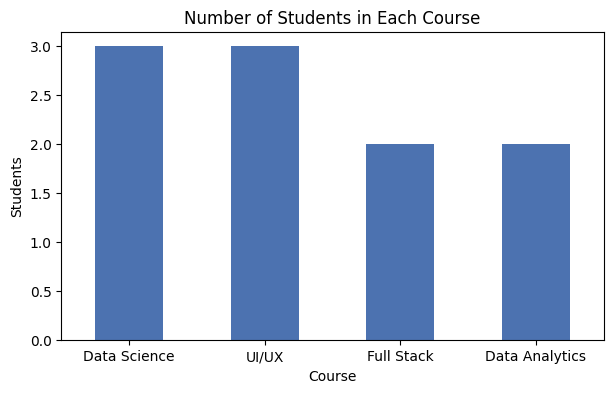

In [30]:
import matplotlib.pyplot as plt

df["course"].value_counts().plot(kind="bar", color="#4C72B0", figsize=(7, 4))
plt.title("Number of Students in Each Course")
plt.xlabel("Course")
plt.ylabel("Students")
plt.xticks(rotation=0)
plt.show()

---
## 📝 Summary — Data Cleaning Cheat Sheet

| Problem | Solution |
|---|---|
| Messy column names | `df.columns.str.strip().str.lower().str.replace(" ", "_")` |
| Duplicate rows | `df.drop_duplicates()` |
| Extra spaces | `.str.strip()` |
| Mixed capital letters | `.str.title()` / `.str.lower()` |
| Different spellings | `.replace({"wrong": "right"})` |
| Numbers stored as text | `pd.to_numeric(..., errors="coerce")` |
| Comma in numbers | `.str.replace(",", "")` |
| Text dates | `pd.to_datetime(..., errors="coerce")` |
| Impossible values | `df.loc[condition, "col"] = np.nan` |
| Missing important data | `df.dropna(subset=["col"])` |
| Missing numbers | `.fillna(median)` |
| Missing text | `.fillna("Unknown")` |
| Save file | `df.to_csv("file.csv", index=False)` |

---
## 🏋️ Practice Tasks (Try Yourself!)

1. Add a new column `result` → `"Pass"` if marks ≥ 75, else `"Fail"`.
   *Hint:* `np.where(df["marks"] >= 75, "Pass", "Fail")`
2. Find which **city** has the most students.
3. Add a new messy row (e.g. name `"  KARAN mehta "`) and check whether your cleaning steps catch it.
4. Instead of filling missing `city` with `"Unknown"`, fill it with the **most common city** (*Hint:* `df["city"].mode()[0]`).
5. Load any real CSV from Kaggle and apply these same 10 steps. 🚀

---
### 🙌 Well done! You have completed your first Data Cleaning project.